<h1>
  Análise de Preços
</h1>

## Bibliotecas

In [2]:
import pandas as pd
import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Funções

In [3]:
from os import truncate
def carregar_df_csv(caminho:str):
    df = pd.read_csv(caminho)
    return df

def transformar_spark(sessao_spark,df:pd.DataFrame):
 return sessao_spark.createDataFrame(df)

def criar_view(df, nome_view):
 return df.createOrReplaceTempView(nome_view)

def executar_sql(sessao_spark, query):
  return sessao_spark.sql(query)

def ver_df(df):
  return df.show(truncate=False)

## ETL

In [4]:
sessao_spark = SparkSession.builder.appName("Análise de NPS").getOrCreate()

In [5]:
caminho_clientes = "data/olist_customers_dataset.csv"
caminho_itens = "data/olist_order_items_dataset.csv"
caminho_pedidos = "data/olist_orders_dataset.csv"
caminho_avaliacoes = "data/olist_order_reviews_dataset.csv"
caminho_produtos = "data/olist_products_dataset.csv"
caminho_vendedores = "data/olist_sellers_dataset.csv"

## Clientes

In [6]:
df_clientes = carregar_df_csv(caminho_clientes)

df_clientes = transformar_spark(sessao_spark,df_clientes)

criar_view(df_clientes,"dim_clientes")

## Itens

In [7]:
df_itens = carregar_df_csv(caminho_itens)

df_itens = transformar_spark(sessao_spark,df_itens)

criar_view(df_itens,"fat_itens")

## Pedidos

In [8]:
df_pedidos = carregar_df_csv(caminho_pedidos)

df_pedidos = transformar_spark(sessao_spark,df_pedidos)

criar_view(df_pedidos,"fat_pedidos")

## Avaliações

In [9]:
df_avaliacoes = carregar_df_csv(caminho_avaliacoes)

df_avaliacoes = transformar_spark(sessao_spark,df_avaliacoes)

criar_view(df_avaliacoes,"dim_avaliacoes")

## Produtos

In [10]:
df_produtos = carregar_df_csv(caminho_produtos)

df_produtos = transformar_spark(sessao_spark,df_produtos)

criar_view(df_produtos,"dim_produtos")

## Vendedores

In [11]:
df_vendedores = carregar_df_csv(caminho_vendedores)

df_vendedores = transformar_spark(sessao_spark,df_vendedores)

criar_view(df_vendedores,"dim_vendedores")

## Unindo a nota ao pedido

In [12]:
consulta_avaliacoes = \
"""
SELECT
p.order_id AS id_pedido,
c.customer_unique_id AS id_cliente,
prod.product_category_name AS categoria_produto,
p.order_status AS status,
av.review_score AS nota,
c.customer_city AS cidade_cliente,
c.customer_state AS estado_cliente,
ROUND(i.price,2) AS valor_produto,
ROUND(i.freight_value,2) AS valor_frete,
ROUND(i.price + i.freight_value,2) AS valor_total,
av.review_creation_date AS data_avaliacao,
p.order_delivered_customer_date AS data_entrega_cliente
FROM fat_pedidos p
INNER JOIN dim_avaliacoes av
ON av.order_id = p.order_id
INNER JOIN dim_clientes c
ON  c.customer_id = p.customer_id
INNER JOIN fat_itens i
ON i.order_id = p.order_id
INNER JOIN dim_produtos prod
ON prod.product_id = i.product_id
WHERE p.order_status = 'delivered'


"""


df_avaliacoes = executar_sql(sessao_spark, consulta_avaliacoes)

In [13]:
ver_df(df_avaliacoes)

+--------------------------------+--------------------------------+----------------------+---------+----+---------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|id_pedido                       |id_cliente                      |categoria_produto     |status   |nota|cidade_cliente |estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao     |data_entrega_cliente|
+--------------------------------+--------------------------------+----------------------+---------+----+---------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|0132451f29a10b66a5cf1bacc85f9afe|aaff146bd210808c7d004a05966472a7|cama_mesa_banho       |delivered|5   |sao goncalo    |RJ            |89.9         |17.88      |107.78     |2017-11-18 00:00:00|2017-11-17 18:58:42 |
|036091098bdc85e780fc3594006276b7|91049771b745aa43500e4c82ed6a2241|cama_mesa_banho       |delivered|5   |sao paulo      |SP            |

In [14]:
criar_view(df_avaliacoes,"fat_pedidos_avaliados")

In [15]:
consulta_aval_somadas = \
"""
SELECT SUM(valor_total) AS total_gasto, estado_cliente
FROM fat_pedidos_avaliados
GROUP BY valor_total, estado_cliente
"""

df_total_gasto = executar_sql(sessao_spark, consulta_aval_somadas)

In [16]:
ver_df(df_total_gasto)

+------------------+--------------+
|total_gasto       |estado_cliente|
+------------------+--------------+
|502.16999999999996|BA            |
|308.2             |MG            |
|199.84            |BA            |
|240.18            |DF            |
|243.71999999999997|SP            |
|373.22            |MG            |
|378.84            |MG            |
|461.3             |MG            |
|110.4             |RS            |
|1098.54           |SP            |
|298.95000000000005|MG            |
|112.22            |RJ            |
|718.9600000000004 |SP            |
|222.14            |MG            |
|169.37            |SP            |
|209.79            |RJ            |
|191.38            |PE            |
|380.88            |RJ            |
|680.22            |SP            |
|118.58            |GO            |
+------------------+--------------+
only showing top 20 rows



## Análise exploratória

In [17]:
# Quantidade de registros
df_avaliacoes.count()

110013

In [18]:
#Quantidade de registros nulos por coluna:

df_avaliacoes.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_avaliacoes.columns
]).show()

+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|id_pedido|id_cliente|categoria_produto|status|nota|cidade_cliente|estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao|data_entrega_cliente|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|        0|         0|                0|     0|   0|             0|             0|            0|          0|          0|             0|                   0|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+



## (1) A nota do pedido influencia diretamente o valor?



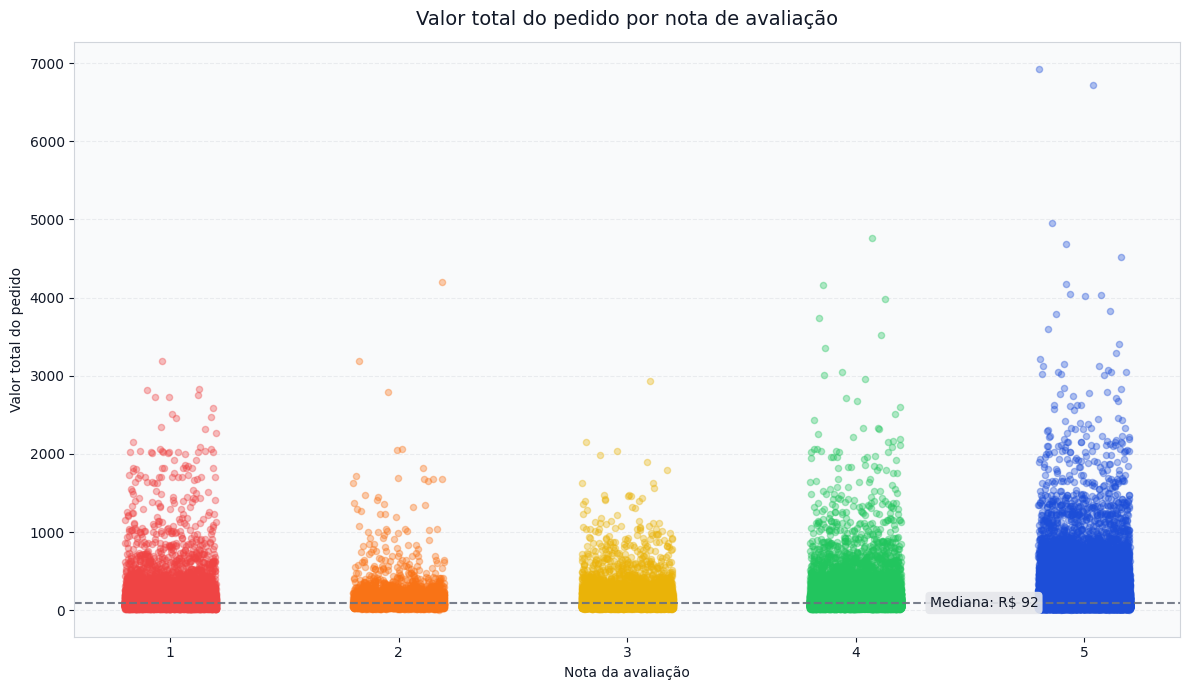

In [19]:
# ============================================================
# GRÁFICO: VALOR TOTAL POR NOTA DE AVALIAÇÃO (REFINADO)
# ============================================================

df_plot = df_avaliacoes.select('nota', 'valor_total').toPandas()

# ------------------------------------------------------------
# Cores por nota (seguindo gradiente lógico)
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",  # vermelho (ruim)
    2: "#F97316",  # laranja
    3: "#EAB308",  # amarelo
    4: "#22C55E",  # verde
    5: "#1D4ED8"   # azul (melhor)
}

# padrão visual
cor_figura = "#FFFFFF"
cor_fundo = "#F9FAFB"
cor_texto = "#111827"
cor_grid = "#D1D5DB"

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot por nota (cores diferentes)
# ------------------------------------------------------------
for nota, df_nota in df_plot.groupby("nota"):
    x_jitter = df_nota["nota"] + np.random.uniform(-0.2, 0.2, size=len(df_nota))

    ax.scatter(
        x_jitter,
        df_nota["valor_total"],
        color=cores_notas.get(nota, "#9CA3AF"),
        alpha=0.35,
        s=20
    )

# ------------------------------------------------------------
# Mediana
# ------------------------------------------------------------
mediana_valor = df_plot["valor_total"].median()

ax.axhline(
    mediana_valor,
    linestyle="--",
    color="#6B7280",
    linewidth=1.5,
    alpha=0.9
)

# BOX da mediana
ax.text(
    4.8,  # joga para direita (evita sobreposição)
    mediana_valor,
    f"Mediana: R$ {mediana_valor:.0f}",
    va="center",
    ha="right",
    fontsize=10,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#E5E7EB",
        edgecolor="none",
        alpha=0.9
    )
)

# ------------------------------------------------------------
# Títulos
# ------------------------------------------------------------
ax.set_title(
    "Valor total do pedido por nota de avaliação",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Valor total do pedido", color=cor_texto)

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis='y', linestyle='--', alpha=0.4, color=cor_grid)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)


plt.tight_layout()
plt.show()

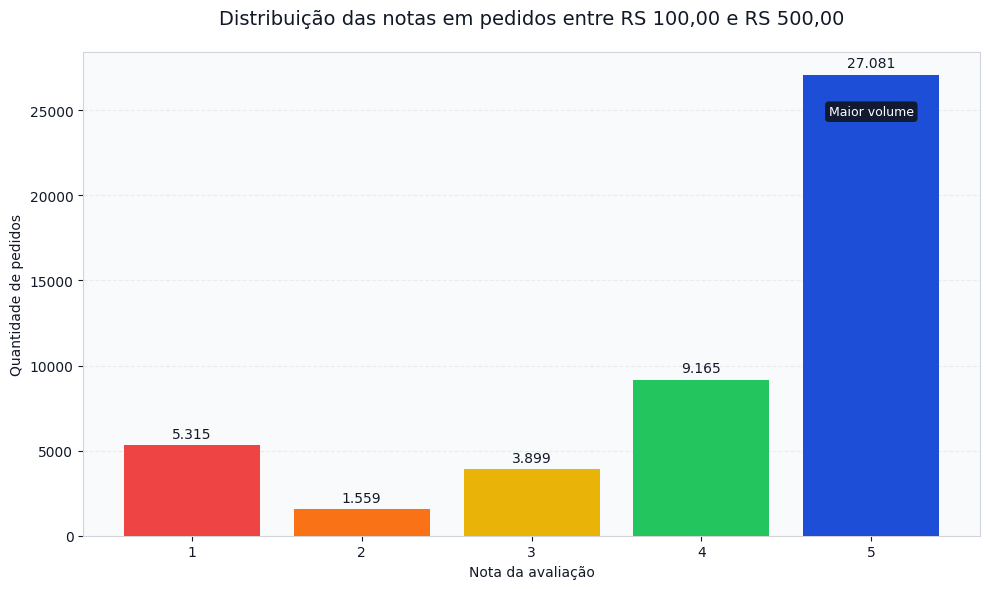

In [30]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 100 E R$ 500
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 100) & 
    (F.col("valor_total") <= 500)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 100,00 e RS 500,00",
    fontsize=14,
    color=cor_texto,
    pad=20  # <-- aumenta espaço
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + (df_contagem_notas_faixa["count"].max() * 0.01),
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque da nota com maior volume
# ------------------------------------------------------------
nota_mais_frequente = df_contagem_notas_faixa.loc[
    df_contagem_notas_faixa["count"].idxmax(),
    "nota"
]

for bar, nota in zip(bars, df_contagem_notas_faixa["nota"]):
    if nota == nota_mais_frequente:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.92,
            "Maior volume",
            ha="center",
            va="center",
            fontsize=9,
            color="#FFFFFF",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#111827",   # fundo escuro
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

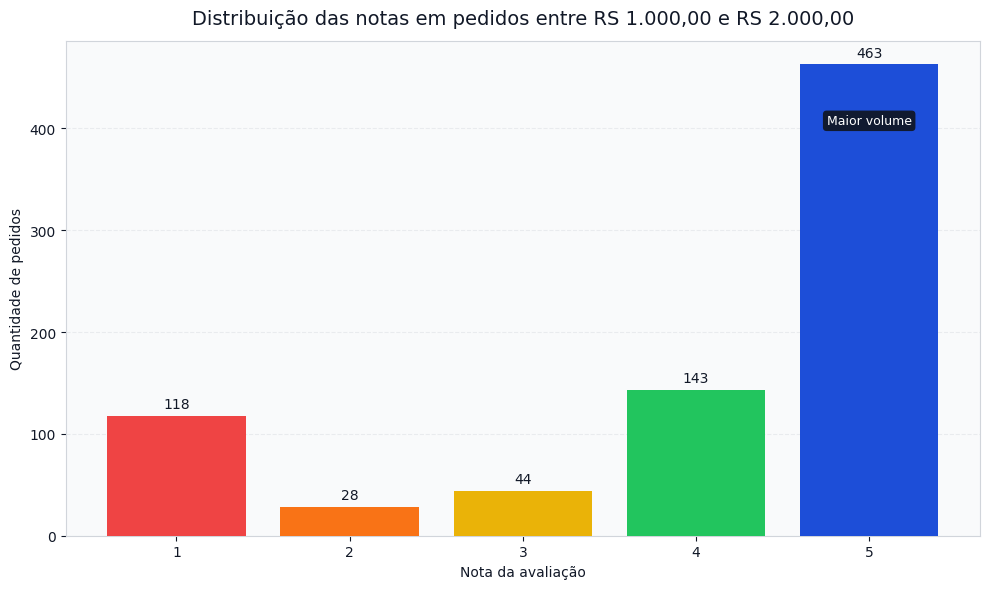

In [32]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 1.000 E R$ 2.000
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 1000) &
    (F.col("valor_total") <= 2000)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 1.000,00 e RS 2.000,00",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + (df_contagem_notas_faixa["count"].max() * 0.01),
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque da nota com maior volume
# ------------------------------------------------------------
nota_mais_frequente = df_contagem_notas_faixa.loc[
    df_contagem_notas_faixa["count"].idxmax(),
    "nota"
]

for bar, nota in zip(bars, df_contagem_notas_faixa["nota"]):
    if nota == nota_mais_frequente:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.88,
            "Maior volume",
            ha="center",
            va="center",
            fontsize=9,
            color="#FFFFFF",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#111827",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

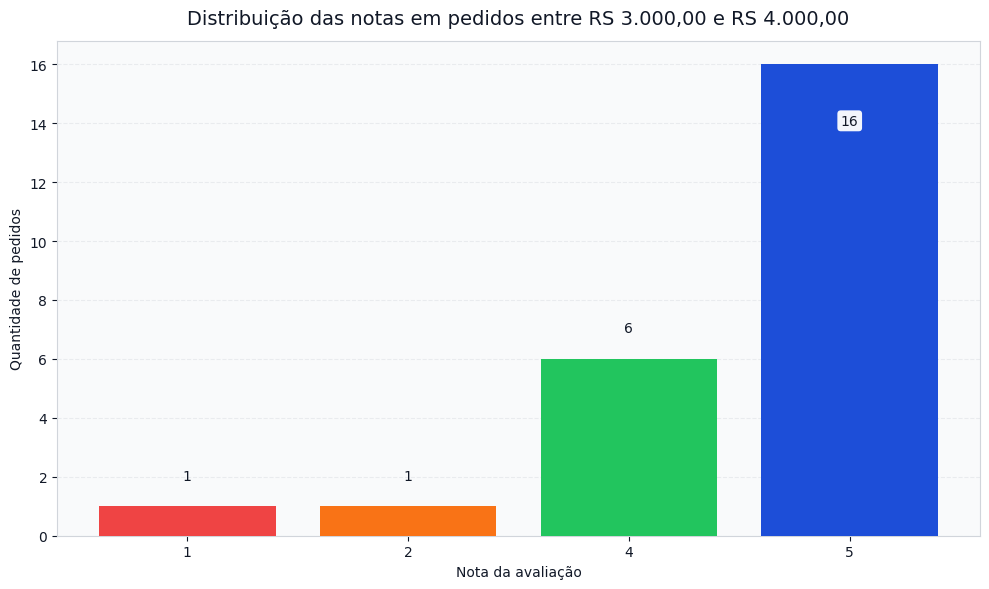

In [36]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 3.000 E R$ 4.000
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 3000) &
    (F.col("valor_total") <= 4000)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota (padrão do projeto)
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3 
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 3.000,00 e RS 4.000,00",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
# Identificar a barra com maior volume
maior_altura = df_contagem_notas_faixa["count"].max()

for bar in bars:
    altura = bar.get_height()

    # MAIOR → dentro com destaque
    if altura == maior_altura:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura * 0.88,
            f"{int(altura)}",
            ha="center",
            va="center",
            fontsize=10,
            color="#111827",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#FFFFFF",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

    # OUTROS → fora da barra
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura + (df_contagem_notas_faixa["count"].max() * 0.05),
            f"{int(altura)}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=cor_texto,
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

## (2) Quais estados possuem as melhores avaliações?

In [23]:
consulta_melhores_estados_avaliacao = """
SELECT
    estado_cliente,
    ROUND(AVG(nota), 2) AS media_nota_avaliacao
FROM fat_pedidos_avaliados
GROUP BY estado_cliente
ORDER BY media_nota_avaliacao DESC
LIMIT 10
"""

df_melhores_estados = executar_sql(sessao_spark, consulta_melhores_estados_avaliacao)

df_melhores_estados_pd = df_melhores_estados.toPandas()

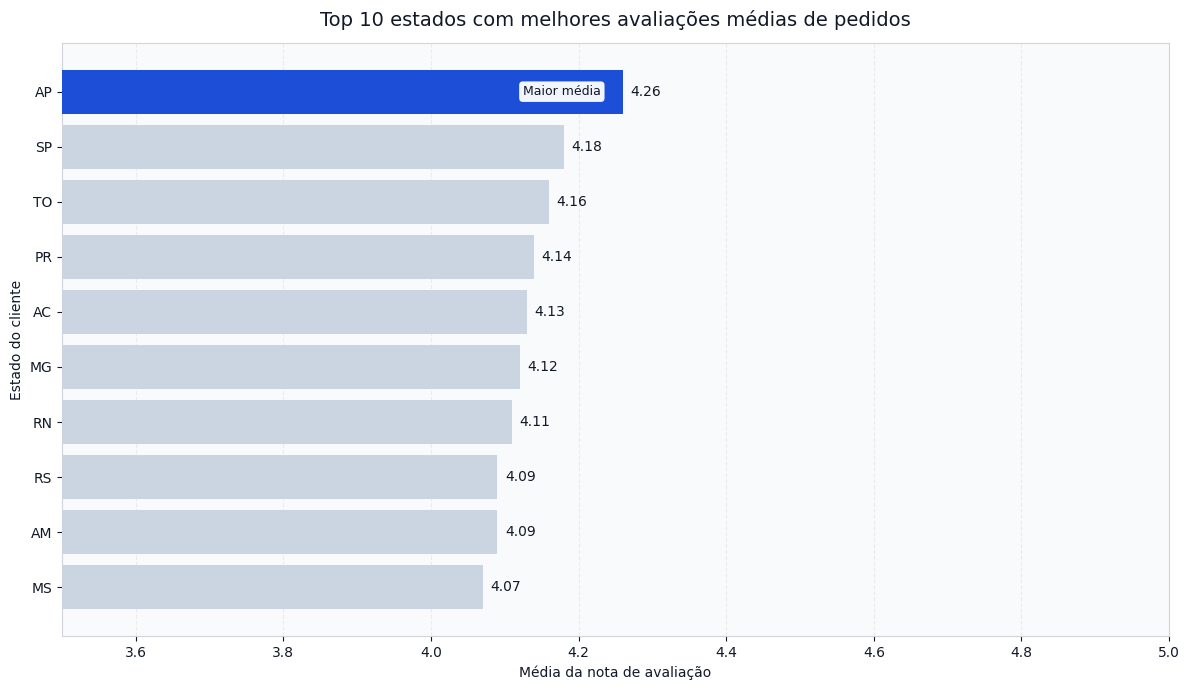

In [42]:
# ============================================================
# GRÁFICO: TOP 10 ESTADOS COM MELHORES AVALIAÇÕES MÉDIAS
# ============================================================

# ------------------------------------------------------------
# Preparar dados
# ------------------------------------------------------------
df_plot = df_melhores_estados_pd.copy()

# Ordenar do menor para o maior para o melhor ficar no topo após invert_yaxis
df_plot = df_plot.sort_values("media_nota_avaliacao", ascending=False)

# Identificar estado com maior média de avaliação
melhor_estado = df_plot.iloc[0]["estado_cliente"]

# ------------------------------------------------------------
# Definir cores
# ------------------------------------------------------------
cores = [
    "#1D4ED8" if estado == melhor_estado else "#CBD5E1"
    for estado in df_plot["estado_cliente"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.barh(
    df_plot["estado_cliente"],
    df_plot["media_nota_avaliacao"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Top 10 estados com melhores avaliações médias de pedidos",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Média da nota de avaliação", color=cor_texto)
ax.set_ylabel("Estado do cliente", color=cor_texto)

# Limite focado na faixa real das notas médias
ax.set_xlim(3.5, 5.0)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    largura = bar.get_width()

    ax.text(
        largura + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{largura:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque do melhor estado
# ------------------------------------------------------------
for bar, estado in zip(bars, df_plot["estado_cliente"]):
    if estado == melhor_estado:
        largura = bar.get_width()
        y_pos = bar.get_y() + bar.get_height() / 2

        ax.text(
            largura - 0.03,
            y_pos,
            "Maior média",
            va="center",
            ha="right",
            fontsize=9,
            color="#111827",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#FFFFFF",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="x", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)
    
ax.invert_yaxis()

plt.tight_layout()
plt.show()